# Importing necessary libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [2]:
pip install pmdarima

# Loading the dataset

In [3]:
forecast_data = pd.read_csv('/content/US_macroeconomics.csv')
forecast_data

,date,CPI,Mortgage_rate,Unemp_rate,NASDAQ,disposable_income,Personal_consumption_expenditure,personal_savings
0,1980-11-01,85.600,14.2050,7.5,200.685556,4976.5,1826.8,11.6
1,1980-12-01,86.400,14.7900,7.2,198.398636,4999.8,1851.7,11.4
2,1981-01-01,87.200,14.9040,7.5,198.817619,4980.4,1870.0,10.9
3,1981-02-01,88.000,15.1325,7.4,194.852105,4965.0,1884.2,10.8
4,1981-03-01,88.600,15.4000,7.4,203.593182,4979.0,1902.9,10.8
...,...,...,...,...,...,...,...,...
494,2022-01-01,281.933,3.4450,4.0,14531.377500,15163.5,16543.3,5.8
495,2022-02-01,284.182,3.7625,3.8,13898.727895,15173.6,16635.8,5.8
496,2022-03-01,287.708,4.1720,3.6,13623.263043,15119.6,16831.2,5.3
497,2022-04-01,288.663,4.9825,3.6,13394.163000,15154.4,16911.2,5.2


# Checking for missing values

In [4]:
forecast_data.isnull().sum()

,0
date,0
CPI,0
Mortgage_rate,0
Unemp_rate,0
NASDAQ,0
disposable_income,0
Personal_consumption_expenditure,0
personal_savings,0


# Statistics about the dataset

In [5]:
forecast_data.describe()

,CPI,Mortgage_rate,Unemp_rate,NASDAQ,disposable_income,Personal_consumption_expenditure,personal_savings
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,178.774886,7.420819,6.180962,2726.419046,9801.916633,7626.305812,7.486573
std,53.252920,3.454838,1.781931,3142.577570,3176.282199,4092.396137,3.015236
min,85.600000,2.684000,3.500000,167.382727,4965.000000,1826.800000,2.100000
25%,134.950000,4.518750,4.900000,479.524773,6861.450000,3910.050000,5.850000
50%,177.400000,6.834000,5.700000,1884.730952,9733.900000,7082.300000,7.200000
75%,227.532500,9.337500,7.250000,3131.357982,12226.100000,10857.300000,8.600000
max,291.474000,18.454000,14.700000,15814.932857,19119.500000,16954.500000,33.800000


# EDA

Visualizing the time series of key columns

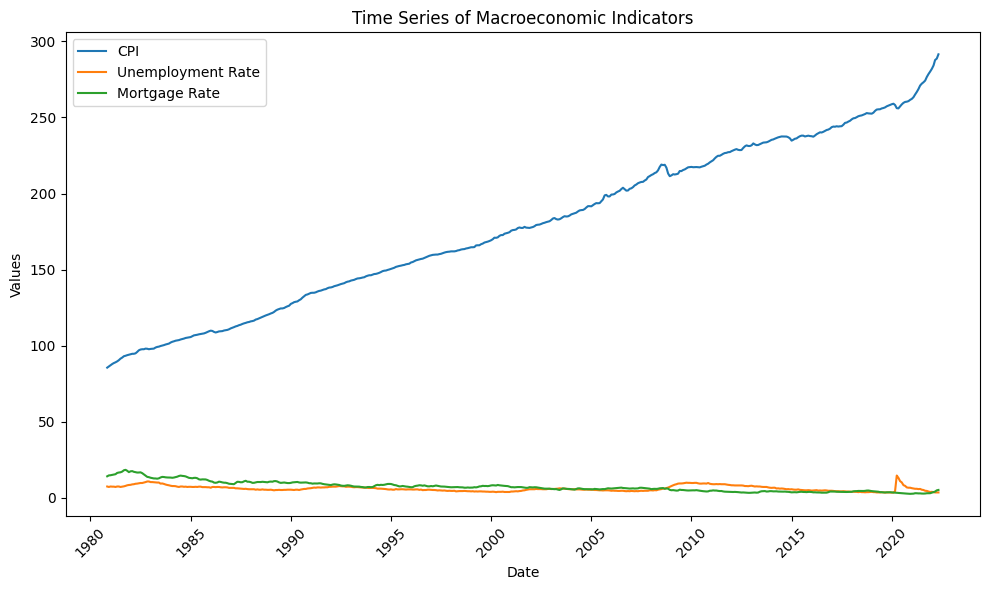

In [6]:
forecast_data['date'] = pd.to_datetime(forecast_data['date'])
plt.figure(figsize=(10, 6))
plt.plot(forecast_data['date'], forecast_data['CPI'], label='CPI')
plt.plot(forecast_data['date'], forecast_data['Unemp_rate'], label='Unemployment Rate')
plt.plot(forecast_data['date'], forecast_data['Mortgage_rate'], label='Mortgage Rate')
plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Time Series of Macroeconomic Indicators')
plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

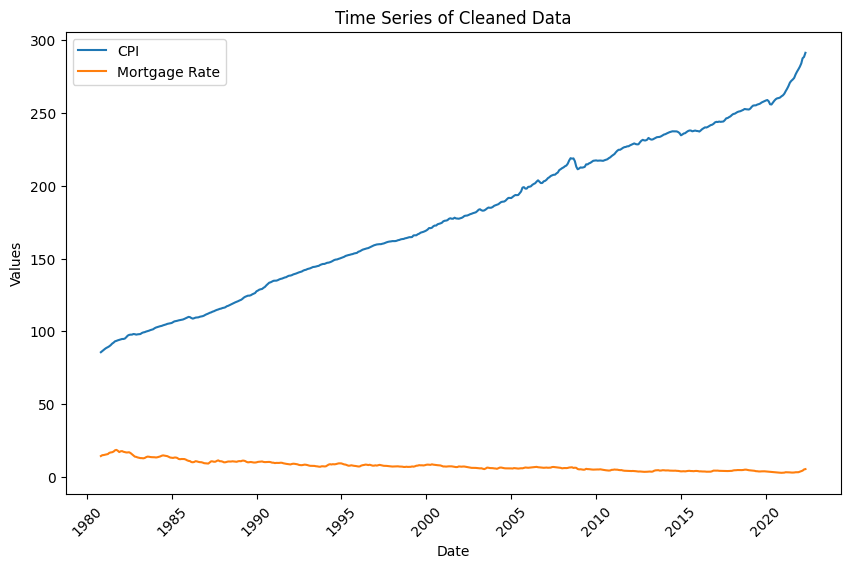

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(forecast_data['date'], forecast_data['CPI'], label='CPI')
plt.plot(forecast_data['date'], forecast_data['Mortgage_rate'], label='Mortgage Rate')
plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Time Series of Cleaned Data')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Visualizing rolling average

In [8]:
forecast_data['CPI_rolling'] = forecast_data['CPI'].rolling(window=3).mean()

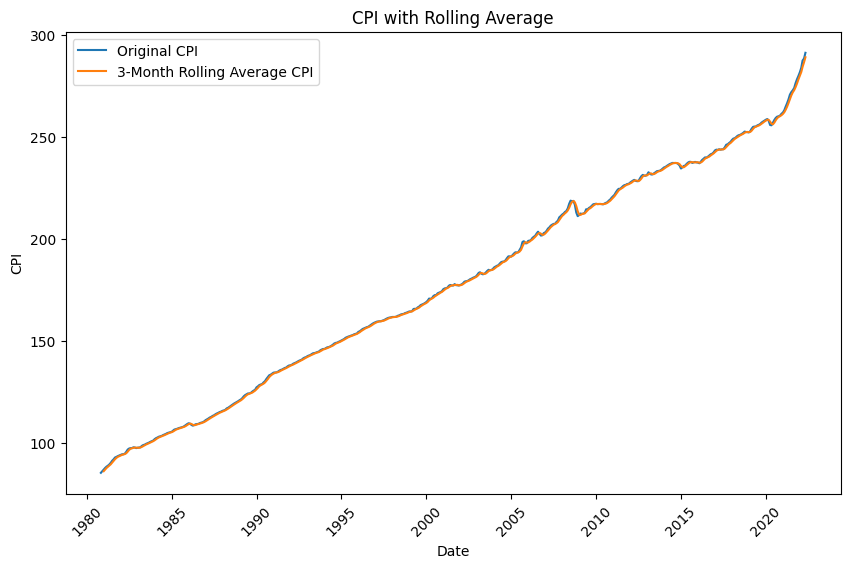

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(forecast_data['date'], forecast_data['CPI'], label='Original CPI')
plt.plot(forecast_data['date'], forecast_data['CPI_rolling'], label='3-Month Rolling Average CPI')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.title('CPI with Rolling Average')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Checking for Stationarity (Augmented Dickey-Fuller Test)

In [10]:
result = adfuller(forecast_data['CPI'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: 1.738943
p-value: 0.998220


ACF and PACF Plots

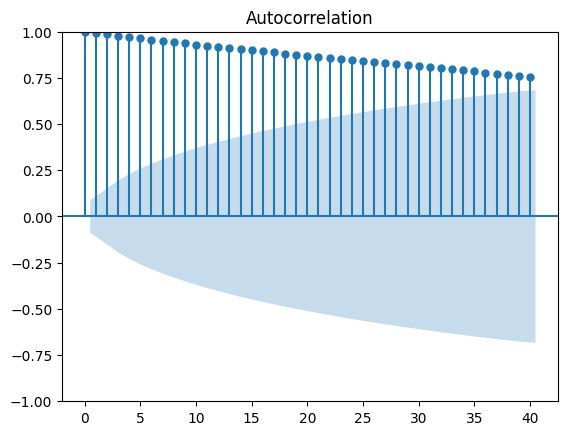

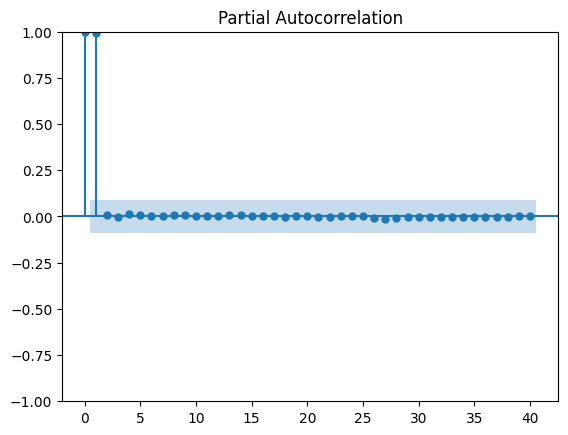

In [11]:
plot_acf(forecast_data['CPI'], lags=40)
plot_pacf(forecast_data['CPI'], lags=40)
plt.show()

# Data Preprocessing

In [12]:
forecast_data['date'] = pd.to_datetime(forecast_data['date'])
forecast_data.set_index('date', inplace=True)

In [13]:
forecast_data = forecast_data.resample('M').mean()

In [14]:
forecast_data['CPI_log'] = np.log(forecast_data['CPI'])

# Seasonal Naive Model

In [15]:
target = 'CPI'

In [16]:
seasonal_period = 12
forecast_data['seasonal_naive_forecast'] = forecast_data[target].shift(seasonal_period)

In [17]:
train_size = int(len(forecast_data) * 0.8)
train, test = forecast_data[:train_size], forecast_data[train_size:]

# Evaluating the model on the test data
y_true = test[target]
y_pred = test['seasonal_naive_forecast']

Displaying evaluation results

In [18]:
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# Display evaluation results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

Mean Absolute Error (MAE): 5.627029999999999
Root Mean Squared Error (RMSE): 7.631715908627627
R-squared (R2): 0.6965530155844136


 Plotting actual vs predicted values

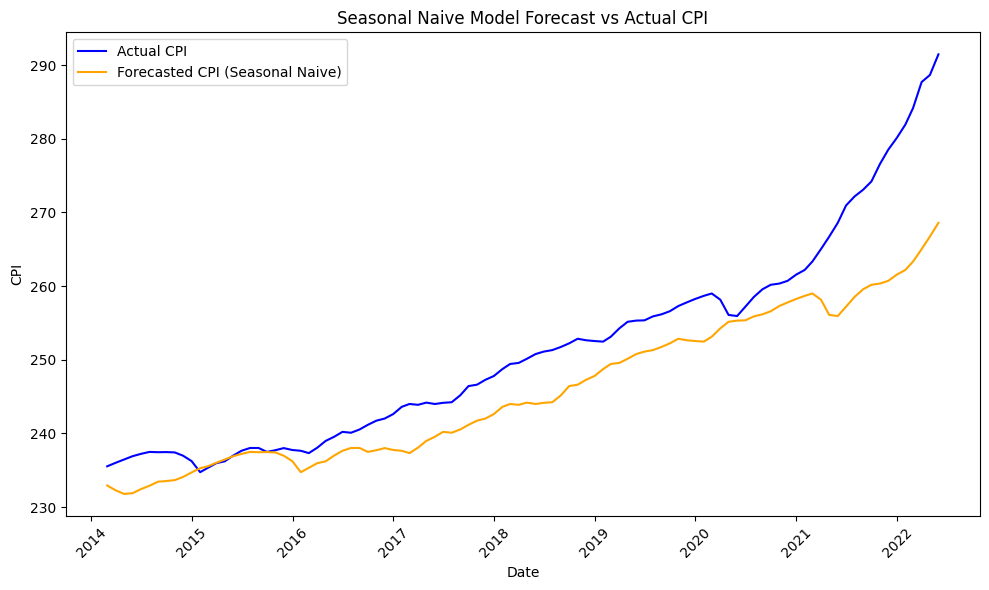

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(test.index, y_true, label='Actual CPI', color='blue')
plt.plot(test.index, y_pred, label='Forecasted CPI (Seasonal Naive)', color='orange')
plt.title('Seasonal Naive Model Forecast vs Actual CPI')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ARIMA model

In [20]:
train_size = int(len(forecast_data) * 0.8)
train, test = forecast_data['CPI_log'][:train_size], forecast_data['CPI_log'][train_size:]

In [21]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fitted = arima_model.fit()

In [22]:
from pmdarima import auto_arima
stepwise_fit = auto_arima(train, start_p=1, start_q=1,
                          max_p=3, max_q=3, m=12,
                          start_P=0, seasonal=True,
                          d=None, D=1, trace=True,
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

print('Optimal ARIMA order:', stepwise_fit.order)
print('Optimal Seasonal ARIMA order:', stepwise_fit.seasonal_order)

best_order = stepwise_fit.order
best_seasonal_order = stepwise_fit.seasonal_order

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=-3510.577, Time=4.99 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-3182.829, Time=0.17 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-3373.445, Time=2.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-3509.623, Time=1.32 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=-3266.181, Time=1.22 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=-3471.857, Time=4.61 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=inf, Time=10.00 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=-3388.021, Time=1.76 sec
 ARIMA(1,1,1)(1,1,2)[12]             : AIC=inf, Time=5.88 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=-3504.075, Time=0.94 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=-3512.367, Time=1.68 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=-3267.961, Time=0.49 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=-3468.067, Time=2.65 sec
 ARIMA(2,1,1)(0,1,2)[12]             : AIC=inf, Time=7.74 sec
 ARIMA(2,1,1)(1,1,0)[1

 Re-fit ARIMA model with the new optimal order found by auto_arima

In [23]:
arima_model = ARIMA(train, order=best_order, seasonal_order=best_seasonal_order)
arima_fitted = arima_model.fit()

In [24]:
print(arima_fitted.summary())

                                    SARIMAX Results                                     
Dep. Variable:                          CPI_log   No. Observations:                  399
Model:             ARIMA(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                1761.184
Date:                          Tue, 05 May 2026   AIC                          -3512.367
Time:                                  11:45:34   BIC                          -3492.588
Sample:                              11-30-1980   HQIC                         -3504.524
                                   - 01-31-2014                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3985      0.283      1.408      0.159      -0.156       0.953
ar.L2         -0.0902      0.149     -0.603      0.

In [25]:
forecast_arima = arima_fitted.forecast(steps=len(test))

Model Evaluation for ARIMA

In [26]:
forecast_arima_exp = np.exp(forecast_arima)
test_exp = np.exp(test)

In [27]:
mae_arima = mean_absolute_error(test_exp, forecast_arima_exp)
rmse_arima = np.sqrt(mean_squared_error(test_exp, forecast_arima_exp))
r2_arima = r2_score(test_exp, forecast_arima_exp)

print(f'MAE for ARIMA: {mae_arima}')
print(f'RMSE for ARIMA: {rmse_arima}')
print(f'R-squared for ARIMA: {r2_arima}')

MAE for ARIMA: 7.246036485684108
RMSE for ARIMA: 7.922393315295178
R-squared for ARIMA: 0.6729973784002667


Plotting actual vs forecasted values

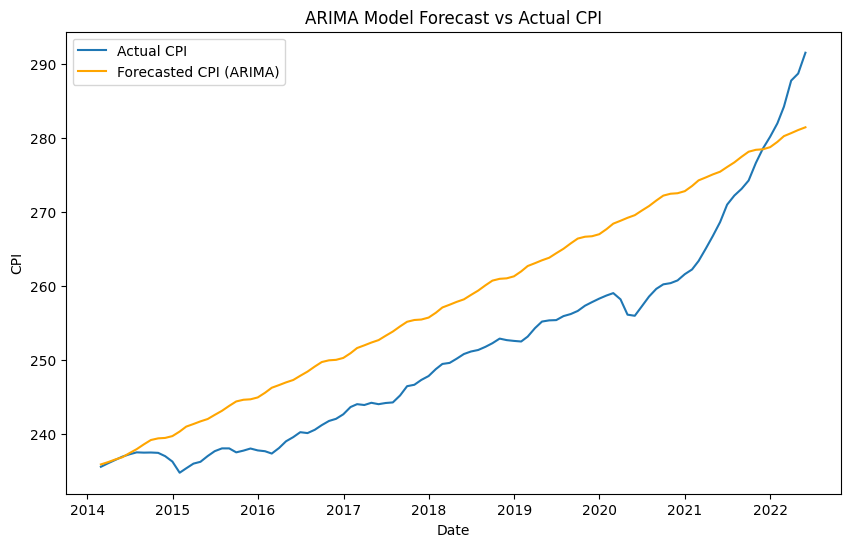

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(test_exp, label='Actual CPI')
plt.plot(forecast_arima_exp, label='Forecasted CPI (ARIMA)', color='orange')
plt.title('ARIMA Model Forecast vs Actual CPI')
plt.xlabel('Date')
plt.ylabel('CPI')
plt.legend()
plt.show()